In [28]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt

from e2e.data.dataset import ShapeDataset
from e2e.helpers import timing

timing.ENABLE_TIMING = True
from e2e.data.loader import EXPERIMENT as EXP
from e2e.models.recurrent import LSTM
from e2e.prediction.end_to_end import DataLoader, ModelHandler, Plotter, Predictor

import scienceplots
plt.style.use(['science', 'ieee', 'grid'])
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"mathtext.default": "regular"})


PROJECT_NAME = "waam-e2e-pre"
RUN_ID = "q2btbt08"

# "oqfrcpcw"
# "oqfrcpcw"
# "isn0h9ws"  # first_in_row + 2x
# "xtuq679p"    # first_in_row + 4x
VERSION = "best"
VM_DATA_DIR = Path("/home/magnus/datasets/waam/30_processing_results/ImageGenerator")
INPUT_LENGTH = 90
TARGET_LENGTH = 90
P = 0.5

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Plot functions

In [35]:
def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlim(0.5, len(labels) + 0.5)

def plot_two_violions(desc, labels, dataset):
    cm = 1 / 2.54
    fig, ax = plt.subplots(figsize=(18 * cm, 10 * cm), dpi=300)
    pos = np.arange(0, 2)
    v1 = ax.violinplot(dataset=dataset, positions=pos+1, widths=0.5, showextrema=False, showmedians=True)
    
    med1 = v1['cmedians']
    med1.set_color('black')
    med1.set_linestyle('-')
    
    ax.set_ylabel(desc["y-axis"])
    ax.set_ylim(0, 1.0)
    set_axis_style(ax, labels)
    plt.show()
    

## Load model

In [38]:
lstm = LSTM(
    p=P, n_input_features=INPUT_LENGTH, n_output_features=TARGET_LENGTH, n_hidden=TARGET_LENGTH * 3, n_layers=10
)
model_handler = ModelHandler(PROJECT_NAME, RUN_ID, VERSION, lstm=lstm)

wandb: Downloading large artifact model-q2btbt08:best, 65.29MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.1


In [50]:
data_loader = DataLoader(VM_DATA_DIR)
cross_section_samples = data_loader.load_samples([EXP.RANDOM_EX6])
dataset = ShapeDataset(mirror=False, segment_length=TARGET_LENGTH).create(cross_section_samples)
predictor = Predictor(TARGET_LENGTH, model_handler, cross_section_samples)

 29%|██▊       | 76/265 [00:01<00:01, 96.09it/s]Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/home/magnus/miniconda3/envs/waam310/lib/python3.10/multiprocessing/queues.py", line 239, in _feed
    reader_close()
  File "/home/magnus/miniconda3/envs/waam310/lib/python3.10/multiprocessing/connection.py", line 177, in close
    self._close()
  File "/home/magnus/miniconda3/envs/waam310/lib/python3.10/multiprocessing/connection.py", line 361, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/magnus/miniconda3/envs/waam310/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/home/magnus/miniconda3/envs/waam310/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/home/magnus/miniconda3/envs/waam310/lib/python3.10/multiprocessing/queues.

In [40]:
UNCERT_THRESH = 5.0
init_input = torch.tensor(dataset[0][0], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
predictions, labels, ground_truth = predictor.predict(init_input, uncertainty_threshold=UNCERT_THRESH, mode="e2e")

/tmp/ipykernel_556140/507628184.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  init_input = torch.tensor(dataset[0][0], dtype=torch.float32).unsqueeze(0).unsqueeze(0)


function predict_with_uncertainty took 0.270843505859375 s
uncertainty_score@0: 3.2916088104248047
function predict_with_uncertainty took 0.24117708206176758 s
uncertainty_score@1: 2.9111547470092773
function predict_with_uncertainty took 0.24097585678100586 s
uncertainty_score@2: 3.03692364692688
function predict_with_uncertainty took 0.2415027618408203 s
uncertainty_score@3: 2.927682876586914
function predict_with_uncertainty took 0.242234468460083 s
uncertainty_score@4: 2.642418622970581
function predict_with_uncertainty took 0.23784327507019043 s
uncertainty_score@5: 2.514836311340332
function predict_with_uncertainty took 0.24013447761535645 s
uncertainty_score@6: 2.9170212745666504
function predict_with_uncertainty took 0.24193191528320312 s
uncertainty_score@7: 2.895372152328491
function predict_with_uncertainty took 0.2390880584716797 s
uncertainty_score@8: 4.483830451965332
function predict_with_uncertainty took 0.24451208114624023 s
uncertainty_score@9: 3.6042115688323975
fun

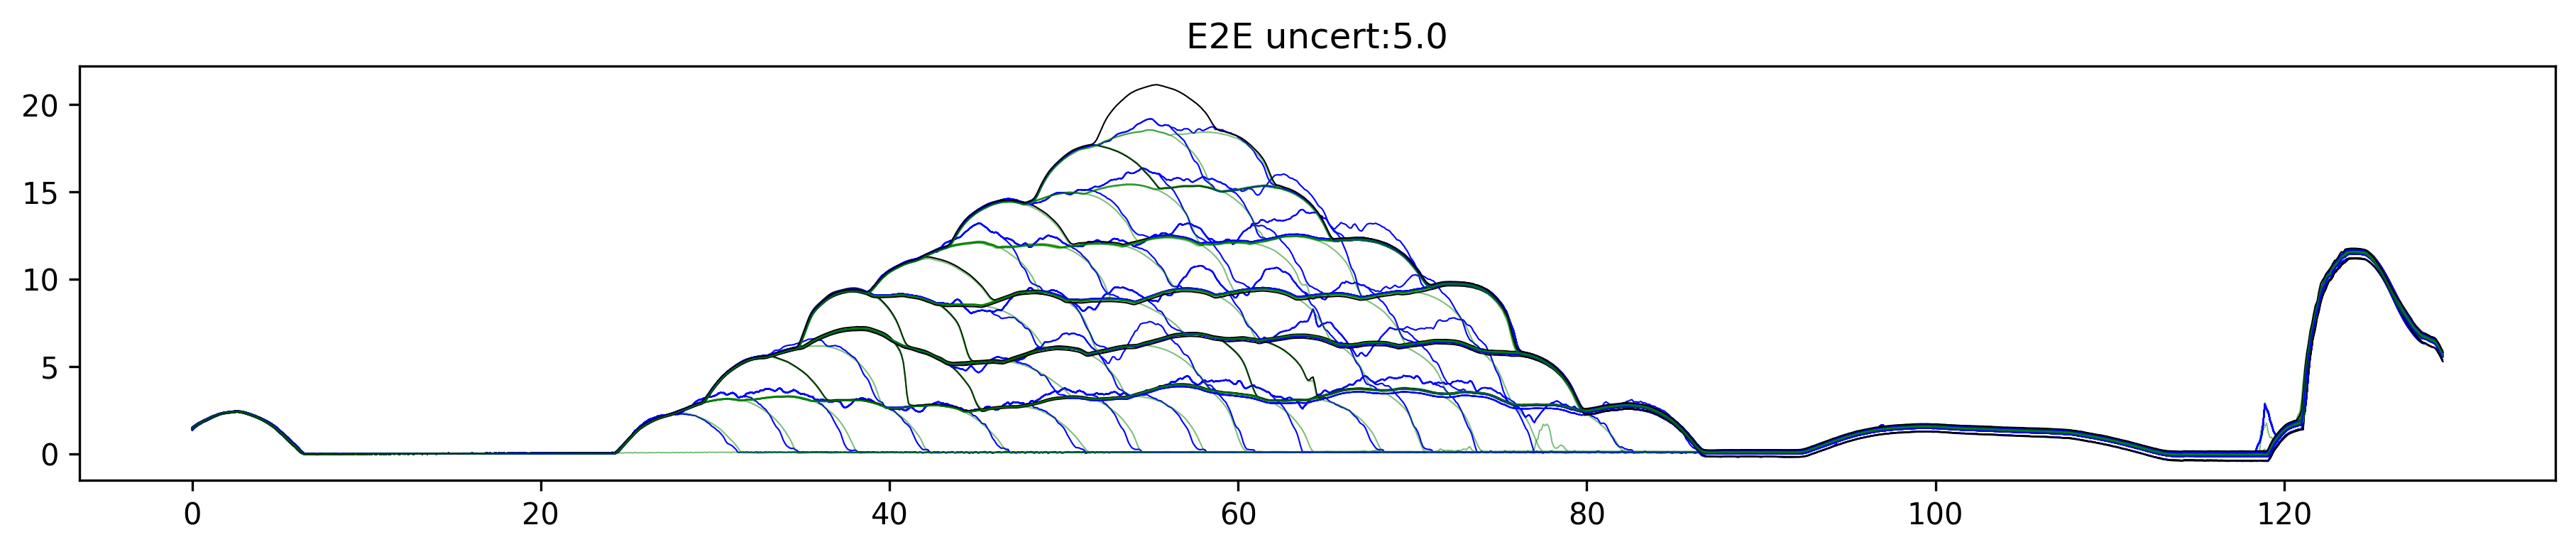

fallback rate to alternative prediction: 23.21%


In [4]:
Plotter.plot_e2e(predictions, labels, ground_truth, title=f"E2E uncert:{UNCERT_THRESH}")
print(f"fallback rate to alternative prediction: {np.sum(labels)/len(labels)*100:.2f}%")

In [37]:
footprint_errors = predictor.footprint_errors
np.array(footprint_errors)

NameError: name 'predictor' is not defined

In [52]:
from e2e.data.datamodule import ShapePredictionDataModule

SEED = 2345078

datamodule = ShapePredictionDataModule(
    batch_size=16,
    data_dir=VM_DATA_DIR,
    workers=1,
    dataset=ShapeDataset(mirror=False, segment_length=TARGET_LENGTH),
    split=[0.7, 0.3, 0],
    train_val_sets=[EXP.CONSTANT_EX3, EXP.CONSTANT_EX4, EXP.RANDOM_EX3, EXP.RANDOM_EX5],
    separate_test_set=EXP.RANDOM_EX6,
    seed=SEED,
)

datamodule.setup(stage="fit")

100%|██████████| 265/265 [00:21<00:00, 12.38it/s]


158
238


100%|██████████| 265/265 [00:07<00:00, 33.45it/s]


## B2B Footprint Error

In [53]:
def calc_mae(df: pd.DataFrame) -> np.array:
    preds = df[["pred (left)", "pred (right)"]].values
    targets = df[["target (left)", "target (right)"]].values
    return np.abs(preds - targets).flatten()

resnet_test_preds = pd.read_csv("/home/magnus/repos/ml-footprint-pred/paper1/data/230427/230427_resnet_test_preds.csv")
resnet_test_preds_ae = calc_mae(resnet_test_preds)

In [56]:
def _find_edge(y_diff, idx_peak, threshold=0.07, which="left"):
    # TODO: use different algorithm: e.g. island finding
    # https://stackoverflow.com/questions/52189433/find-the-first-index-for-which-an-array-goes-below-a-certain-threshold-and-stay
    if which == "left":
        sign = -1
    elif which == "right":
        sign = 1
    else:
        raise ValueError(f"which={which} is undefined.")

    k = 0
    while y_diff[idx_peak + sign * k] >= threshold:
        k += 1

        if (idx_peak + sign * k) < 0 or (idx_peak + sign * k) >= len(y_diff):
            # TODO: find out in which cases this happens and whether it can be avoided
            print(f"FootprintDetection: - index out of bounds for k={k}")
            # Correcting k by {sign} and skipping.
            k -= sign
            break

    return idx_peak + sign * k

In [73]:
model = model_handler
dataloader = datamodule.test_dataloader()
footprint_errors = []

for batch in dataloader:
    inputs, targets, ids, fp = batch
    
    pred_diff, *_ = model.model(inputs.to(model.model.device))
    pred_diff = pred_diff.detach().cpu().numpy()
    
    mid_idx = inputs.shape[-1] // 2
    left_fp = max(0, _find_edge(pred_diff, mid_idx, threshold=0.1, which="left"))
    right_fp = min(90, _find_edge(pred_diff, mid_idx, threshold=0.1, which="right"))
    
    left_fp_err = np.abs(left_fp - fp[:, 0]).cpu().numpy().flatten().tolist()
    right_fp_err = np.abs(right_fp - fp[:, 1]).cpu().numpy().flatten().tolist()
    
    footprint_errors.extend([left_fp_err, right_fp_err])
    
    

In [76]:
# flatten list
fp_errors = [item * 0.1 for sublist in footprint_errors for item in sublist]

In [77]:
len(fp_errors)

112

In [78]:
len(resnet_test_preds_ae)

112

2023-09-28 10:36:59,177 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:36:59,179 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:36:59,181 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:36:59,203 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:36:59,204 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:36:59,206 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:36:59,207 - MainThread - INFO - matplotlib.texmanager - No LaT

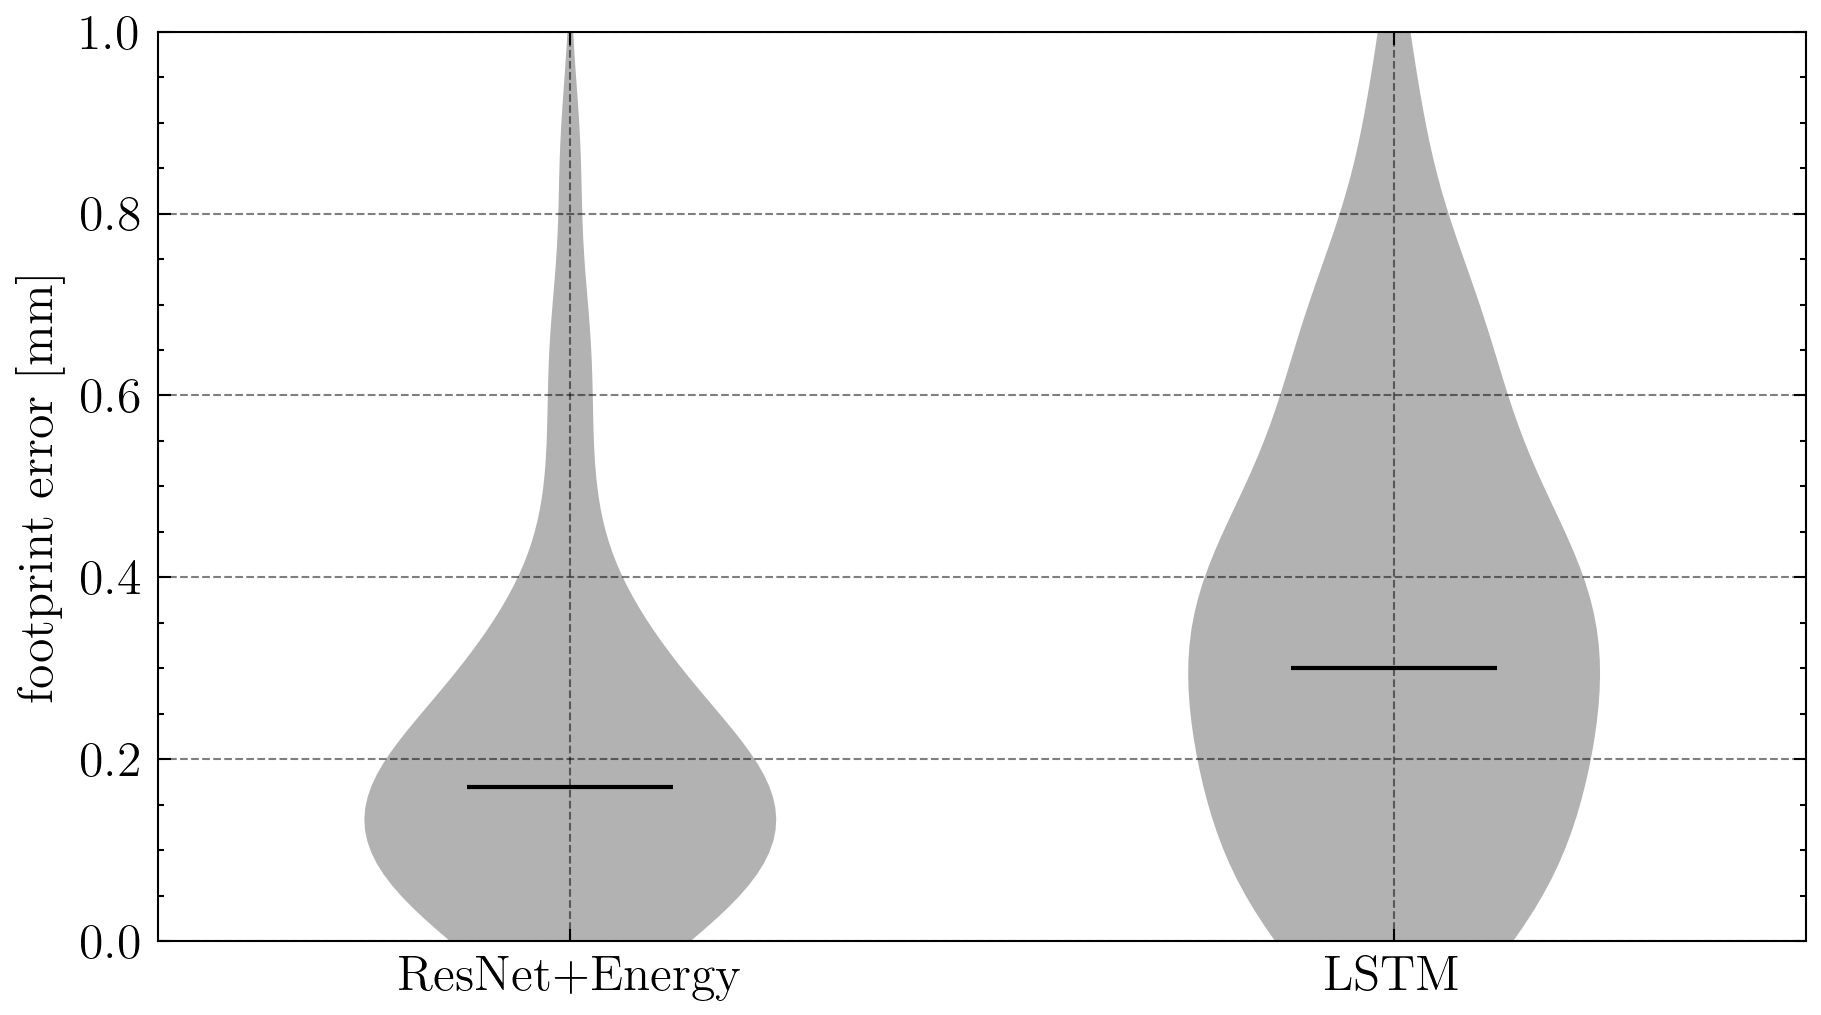

In [79]:
desc = {
    "title": "",
    "x-axis": "",
    "y-axis": "footprint error $[\mathrm{mm}]$"
}

labels = ["ResNet+Energy", "LSTM"]

plot_two_violions(desc, labels, [np.array(resnet_test_preds_ae), np.array(fp_errors)])

## B2B Mod Hausdorff Shape Error

In [58]:
datamodule.setup(stage="fit")

100%|██████████| 265/265 [00:21<00:00, 12.59it/s]


158
238


100%|██████████| 265/265 [00:07<00:00, 33.70it/s]


In [7]:
from scipy.spatial.distance import cdist
model = model_handler
val_data_loader = datamodule.test_dataloader()
modhaussdorff = []

for batch in val_data_loader:
    inputs, targets, ids, fp = batch
    
    pred_diff, *_ = model.model(inputs.to(model.model.device))
    preds = inputs + pred_diff.detach().cpu()
    
    x = np.arange(0, len(preds) / 10, 0.1)
    
    for b in range(len(preds)):
        left = fp[b, 0]
        right = fp[b, 1]
        dist = cdist(list(zip(x, targets[b, left:right])), list(zip(x, preds[b, left:right])))
        modhaussdorff.append((np.median(np.min(dist, axis=1))))
        

In [8]:
len(modhaussdorff)

56

In [10]:
b2b_resnet_energy = np.loadtxt("/home/magnus/repos/ml-footprint-pred/paper1/b2b_results/data/b2b_losses_fp:Resnet-g2cyy7rt_shape:Energy2.csv")

In [11]:
len(b2b_resnet_energy)

56

2023-09-28 10:20:24,580 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:20:24,582 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:20:24,583 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:20:24,604 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:20:24,605 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:20:24,607 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:20:24,608 - MainThread - INFO - matplotlib.texmanager - No LaT

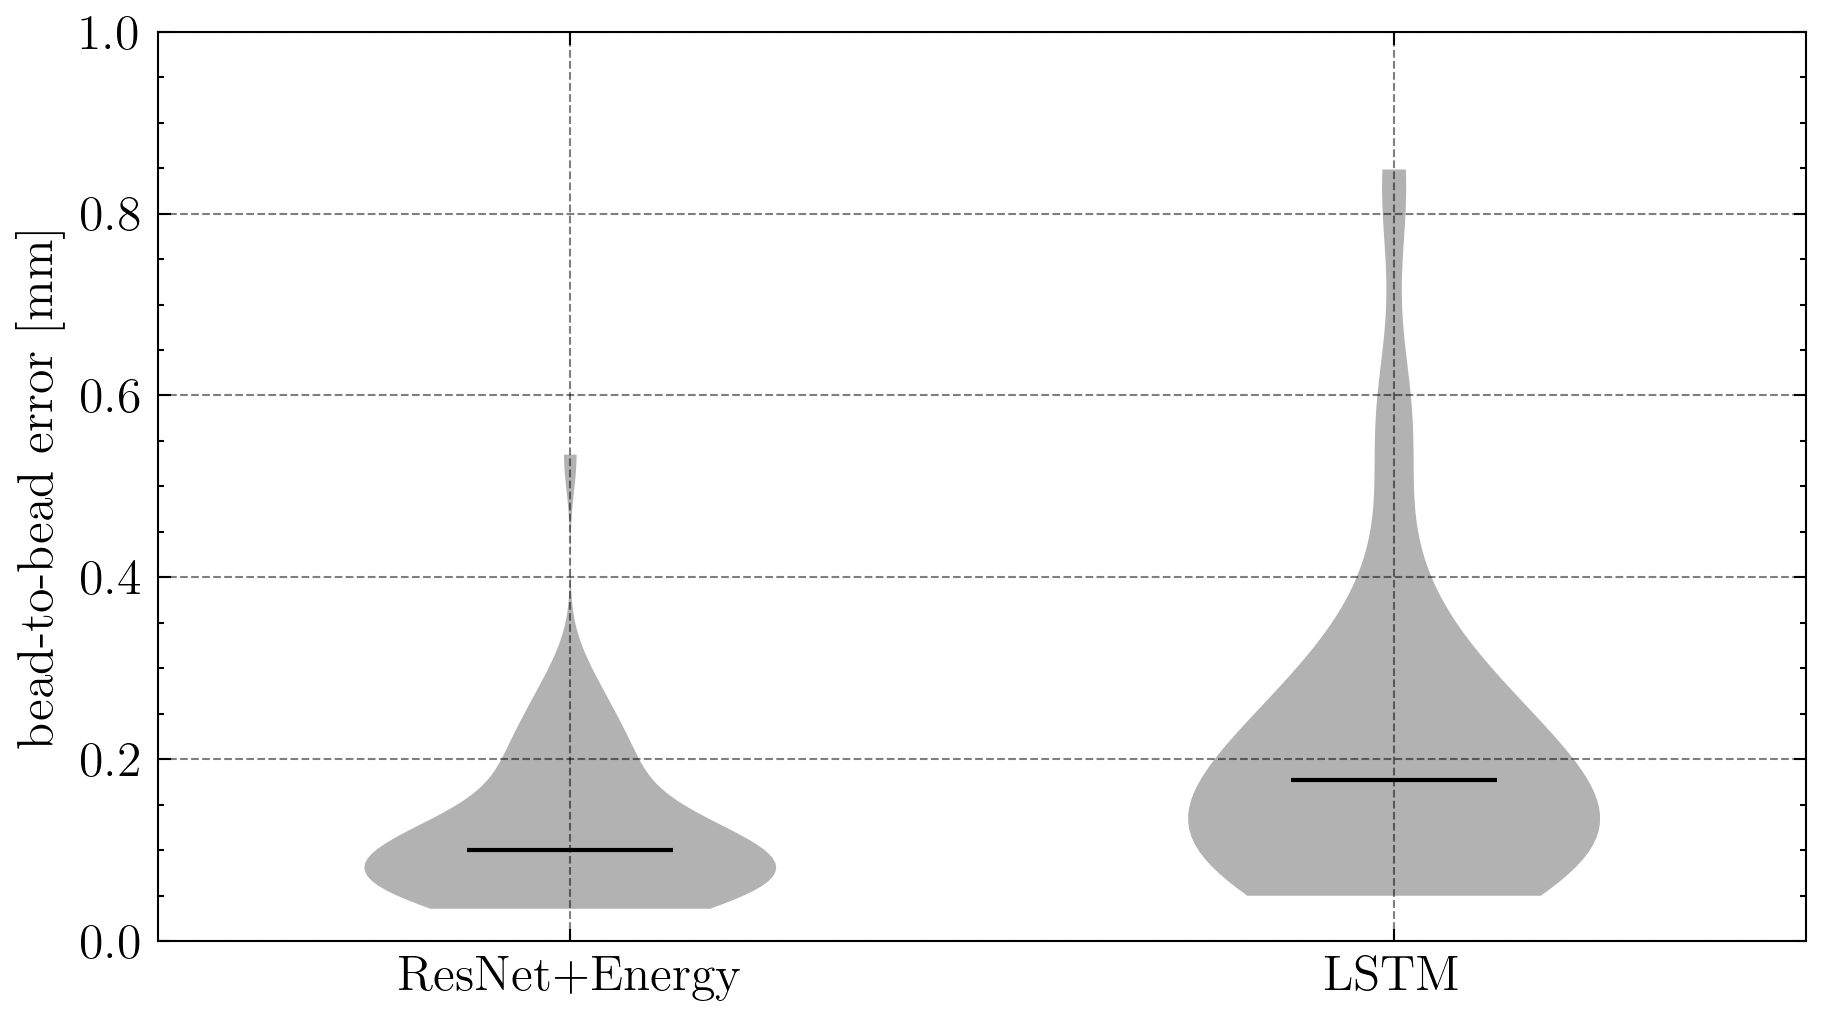

In [34]:
desc = {
    "title": "",
    "x-axis": "",
    "y-axis": "bead-to-bead error $[\mathrm{mm}]$"
}

labels = ["ResNet+Energy", "LSTM"]

plot_two_violions(desc, labels, [np.array(b2b_resnet_energy), np.array(modhaussdorff)])

In [24]:
import numpy as np
from scipy.stats import ttest_ind, boxcox, shapiro
import matplotlib.pyplot as plt

# Generate non-normal data for the example
np.random.seed(42)
sample_1 = b2b_resnet_energy
sample_2 = modhaussdorff

# Apply Box-Cox transformation
sample_1_transformed, _ = boxcox(sample_1)
sample_2_transformed, _ = boxcox(sample_2)

# Check normality using Shapiro-Wilk test
_, p_value_1 = shapiro(sample_1_transformed)
_, p_value_2 = shapiro(sample_2_transformed)

if p_value_1 > 0.05 and p_value_2 > 0.05:
    print("Both transformed samples appear to be normally distributed.")
else:
    print("One or both transformed samples do not appear to be normally distributed.")

# Conduct the t-test for independent samples on transformed data
t_stat, p_value = ttest_ind(sample_1_transformed, sample_2_transformed)

# Choose a significance level
alpha = 0.05

# Make a decision based on the p-value
if p_value < alpha:
    print(f"Reject the null hypothesis (p-value = {p_value:.4f})")
    print("The means of the two transformed samples are statistically different.")
else:
    print(f"Fail to reject the null hypothesis (p-value = {p_value:.4f})")
    print("The means of the two transformed samples are not statistically different.")


Both transformed samples appear to be normally distributed.
Reject the null hypothesis (p-value = 0.0000)
The means of the two transformed samples are statistically different.


2023-09-28 10:11:32,152 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:11:32,154 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:11:32,155 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:11:32,155 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:11:32,351 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:11:32,353 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-09-28 10:11:32,353 - MainThread - INFO - matplotlib.texmanager - No LaT

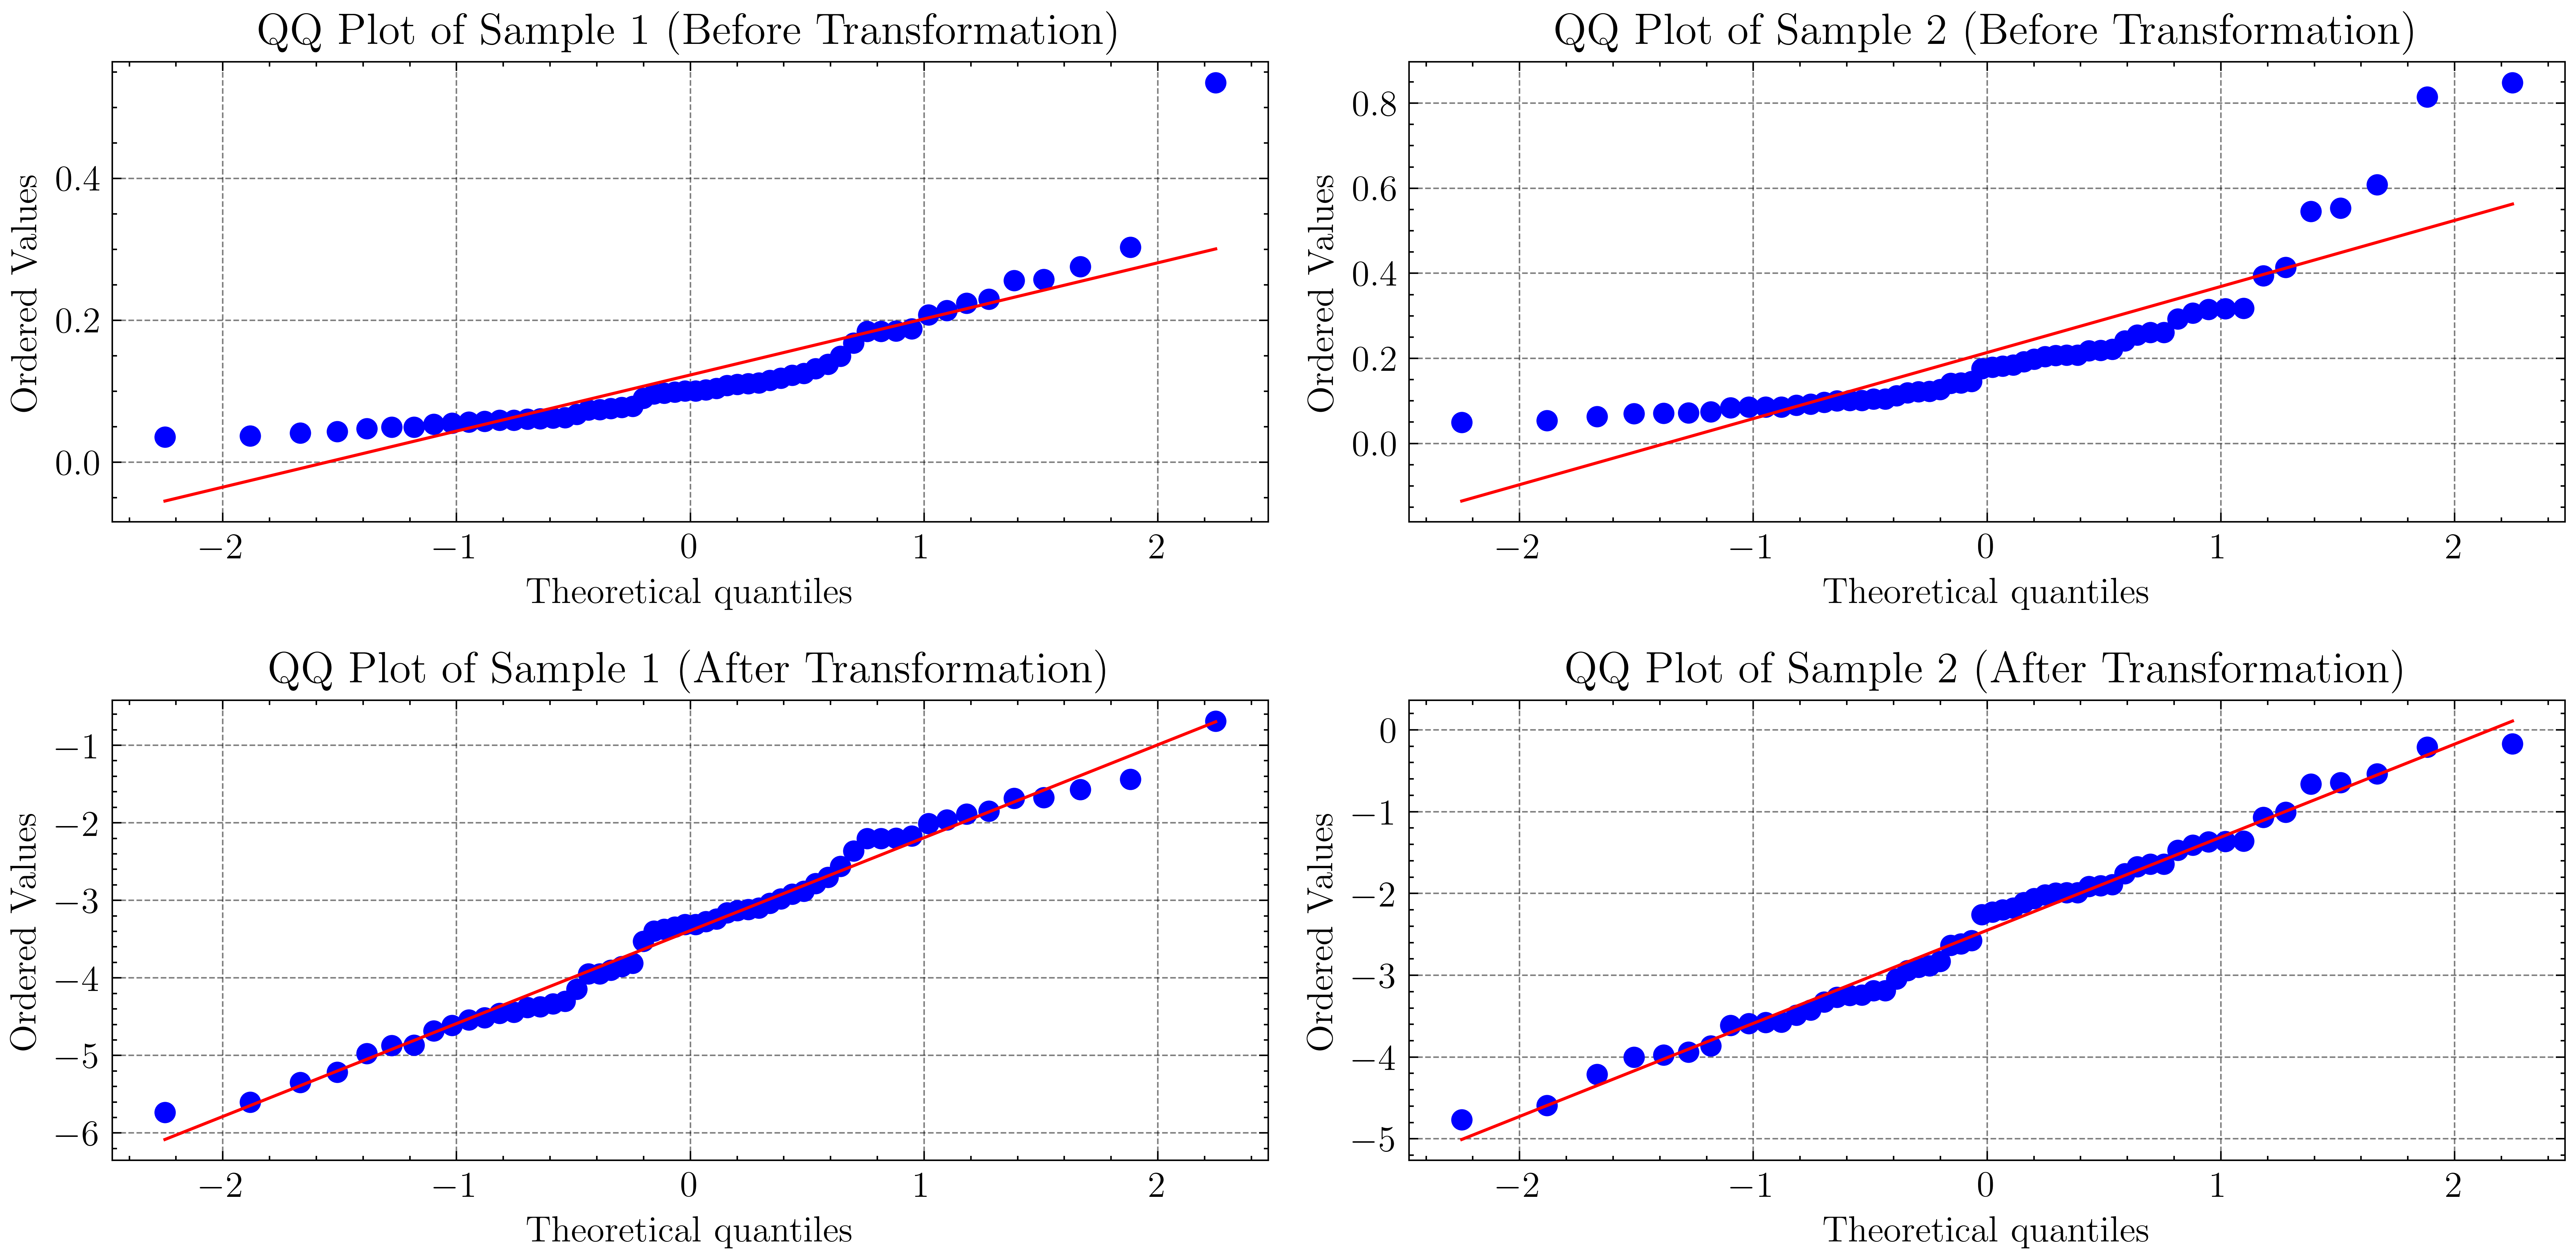

In [25]:
from scipy.stats import boxcox, probplot

# QQ plots before transformation
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
probplot(sample_1, dist="norm", plot=plt)
plt.title("QQ Plot of Sample 1 (Before Transformation)")

plt.subplot(2, 2, 2)
probplot(sample_2, dist="norm", plot=plt)
plt.title("QQ Plot of Sample 2 (Before Transformation)")

# QQ plots after transformation
plt.subplot(2, 2, 3)
probplot(sample_1_transformed, dist="norm", plot=plt)
plt.title("QQ Plot of Sample 1 (After Transformation)")

plt.subplot(2, 2, 4)
probplot(sample_2_transformed, dist="norm", plot=plt)
plt.title("QQ Plot of Sample 2 (After Transformation)")

plt.tight_layout()
plt.show()